In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression


df = pd.read_csv('House_Price_dataset - House_Price_dataset.csv')

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4.0,2.0,3.0,yes,no,no,no,yes,2.0,yes,furnished
1,12250000,8960,4.0,4.0,4.0,yes,no,no,no,yes,3.0,no,furnished
2,12250000,9960,3.0,2.0,2.0,yes,no,yes,no,no,2.0,yes,semi-furnished
3,12215000,7500,4.0,2.0,2.0,yes,no,yes,no,yes,3.0,yes,furnished
4,11410000,7420,4.0,1.0,2.0,yes,yes,yes,no,yes,2.0,no,furnished


In [8]:
df.shape

(545, 13)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    int64  
 1   area              545 non-null    int64  
 2   bedrooms          540 non-null    float64
 3   bathrooms         540 non-null    float64
 4   stories           543 non-null    float64
 5   mainroad          545 non-null    str    
 6   guestroom         545 non-null    str    
 7   basement          545 non-null    str    
 8   hotwaterheating   545 non-null    str    
 9   airconditioning   545 non-null    str    
 10  parking           541 non-null    float64
 11  prefarea          545 non-null    str    
 12  furnishingstatus  545 non-null    str    
dtypes: float64(4), int64(2), str(7)
memory usage: 55.5 KB


In [10]:
df.isna().sum()

price               0
area                0
bedrooms            5
bathrooms           5
stories             2
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             4
prefarea            0
furnishingstatus    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())
df["stories"] = df["stories"].fillna(df["stories"].median())
df["parking"] = df["parking"].fillna(df["parking"].median())



In [13]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [14]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4.0,2.0,3.0,yes,no,no,no,yes,2.0,yes,furnished
1,12250000,8960,4.0,4.0,4.0,yes,no,no,no,yes,3.0,no,furnished
2,12250000,9960,3.0,2.0,2.0,yes,no,yes,no,no,2.0,yes,semi-furnished
3,12215000,7500,4.0,2.0,2.0,yes,no,yes,no,yes,3.0,yes,furnished
4,11410000,7420,4.0,1.0,2.0,yes,yes,yes,no,yes,2.0,no,furnished


In [15]:
from sklearn.preprocessing import LabelEncoder

trans_col = df["mainroad"]
le = LabelEncoder()

df["mainroad"] = le.fit_transform(trans_col)
df["guestroom"] = le.fit_transform(df["guestroom"])
df["basement"] = le.fit_transform(df["basement"])
df["hotwaterheating"] = le.fit_transform(df["hotwaterheating"])
df["airconditioning"] = le.fit_transform(df["airconditioning"])
df["prefarea"] = le.fit_transform(df["prefarea"])

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4.0,2.0,3.0,1,0,0,0,1,2.0,1,furnished
1,12250000,8960,4.0,4.0,4.0,1,0,0,0,1,3.0,0,furnished
2,12250000,9960,3.0,2.0,2.0,1,0,1,0,0,2.0,1,semi-furnished
3,12215000,7500,4.0,2.0,2.0,1,0,1,0,1,3.0,1,furnished
4,11410000,7420,4.0,1.0,2.0,1,1,1,0,1,2.0,0,furnished


In [16]:
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4.0,2.0,3.0,1,0,0,0,1,2.0,1,False,False
1,12250000,8960,4.0,4.0,4.0,1,0,0,0,1,3.0,0,False,False
2,12250000,9960,3.0,2.0,2.0,1,0,1,0,0,2.0,1,True,False
3,12215000,7500,4.0,2.0,2.0,1,0,1,0,1,3.0,1,False,False
4,11410000,7420,4.0,1.0,2.0,1,1,1,0,1,2.0,0,False,False


In [24]:
df = df.astype(int)


In [25]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

X = df[["area"]]
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

r2 = r2_score(y_test,y_pred)

print("mae :",mae)
print("mse :",mse)
print("r2 :",r2)

mae : 1474748.1337969352
mse : 3675286604768.185
r2 : 0.27287851871974644


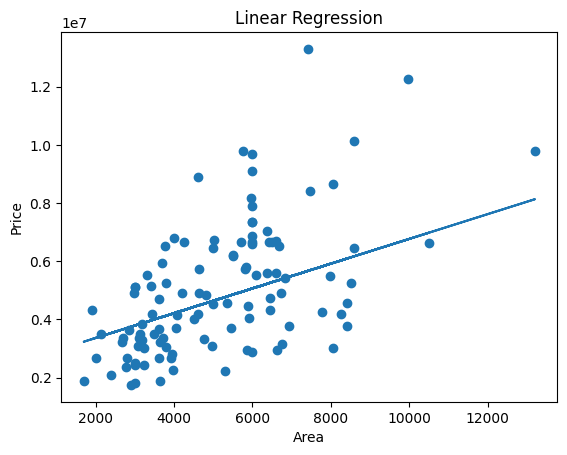

In [26]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linear Regression")


plt.show()

In [27]:
X2 = df[["area","bedrooms","bathrooms","airconditioning","parking","stories"]]
y2 = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)


model2 = LinearRegression()

model2.fit(X_train,y_train)

y_pred = model2.predict(X_test)

mae2 = mean_absolute_error(y_test,y_pred)

mse2 = mean_squared_error(y_test,y_pred)

r22 = r2_score(y_test,y_pred)

print("mae :",mae2)
print("mse :",mse2)
print("r2 :",r22)


mae : 1091084.6562762777
mse : 2075758124137.2893
r2 : 0.5893304429526455


In [28]:
from sklearn.preprocessing import PolynomialFeatures

X3 = df.drop("price", axis=1)
y3 = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

print(X_test)
poly = PolynomialFeatures(degree = 2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

polymodel = LinearRegression()
polymodel.fit(X_train_poly,y_train)



y_pred_poly = polymodel.predict(X_test_poly)
mae3 = mean_absolute_error(y_test,y_pred_poly)
mse3 = mean_squared_error(y_test,y_pred_poly)

r23 = r2_score(y_test,y_pred_poly)

print("mae :",mae3)
print("mse :",mse3)
print("r2 :",r23)




     area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
316  5900         4          2        2         0          0         1   
77   6500         3          2        3         1          0         0   
360  4040         2          1        1         1          0         0   
90   5000         3          1        2         1          0         0   
493  3960         3          1        1         1          0         0   
..    ...       ...        ...      ...       ...        ...       ...   
15   6000         4          1        2         1          0         1   
357  6930         4          1        2         0          0         0   
39   6000         4          2        4         1          0         0   
54   6000         3          2        2         1          1         0   
155  6100         3          2        1         1          0         1   

     hotwaterheating  airconditioning  parking  prefarea  \
316                0                0        1     

In [31]:
area = float(input("Enter area: "))
bedrooms = int(input("Enter bedrooms: "))
bathrooms = int(input("Enter bathrooms: "))
stories = int(input("Enter stories: "))
mainroad = int(input("Enter mainroad (0/1): "))
guestroom = int(input("Enter guestroom (0/1): "))
basement = int(input("Enter basement (0/1): "))
hotwaterheating = int(input("Enter hotwaterheating (0/1): "))
airconditioning = int(input("Enter airconditioning (0/1): "))
parking = int(input("Enter parking spaces: "))
prefarea = int(input("Enter prefarea (0/1): "))
semi_furnished = int(input("Enter semi-furnished (0/1): "))
unfurnished = int(input("Enter unfurnished (0/1): "))


in_params = pd.DataFrame([[
    area,
    bedrooms,
    bathrooms,
    stories,
    mainroad,
    guestroom,
    basement,
    hotwaterheating,
    airconditioning,
    parking,
    prefarea,
    semi_furnished,
    unfurnished
]], columns=X3.columns)

X_input_poly = poly.transform(in_params)

y_predict = polymodel.predict(X_input_poly)

print("Predicted Price:", y_predict[0])


Enter area:  3000
Enter bedrooms:  1
Enter bathrooms:  1
Enter stories:  1
Enter mainroad (0/1):  1
Enter guestroom (0/1):  1
Enter basement (0/1):  1
Enter hotwaterheating (0/1):  1
Enter airconditioning (0/1):  1
Enter parking spaces:  1
Enter prefarea (0/1):  1
Enter semi-furnished (0/1):  1
Enter unfurnished (0/1):  0


Predicted Price: 4668871.328758668
